In [2]:
import numpy as np
import pandas as pd
import cv2
import PIL
import gc
import psutil
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from math import ceil
import math
import sys
import gc
import os
import random
from shutil import copyfile
import datetime

In [3]:
BASE_PATH = r"D:\UNH Materials\Projects\Covid 19 Detection\archive\COVID-19_Radiography_Dataset"
COVID_DATA_PATH = r"D:\UNH Materials\Projects\Covid 19 Detection\archive\COVID-19_Radiography_Dataset\COVID\images\\"
NORMAL_DATA_PATH = r"D:\UNH Materials\Projects\Covid 19 Detection\archive\COVID-19_Radiography_Dataset\NORMAL\images\\"

### Analayzed the dataset

In [3]:
covid_files = len(os.listdir(COVID_DATA_PATH))
normal_files = len(os.listdir(NORMAL_DATA_PATH))

print(f"COVID-19 Xray Scans: {covid_files}")
print(f"Normal Xray Scans: {normal_files}")

COVID-19 Xray Scans: 3616
Normal Xray Scans: 10192


As Observed we may need to sample some 3600 examples from normal scans to keep the dataset balanced, lets do that and create the correct folder structure for the training and testing dataset.

### Let's Visualize the chest X-rays

#### Normal Chest X-rays 

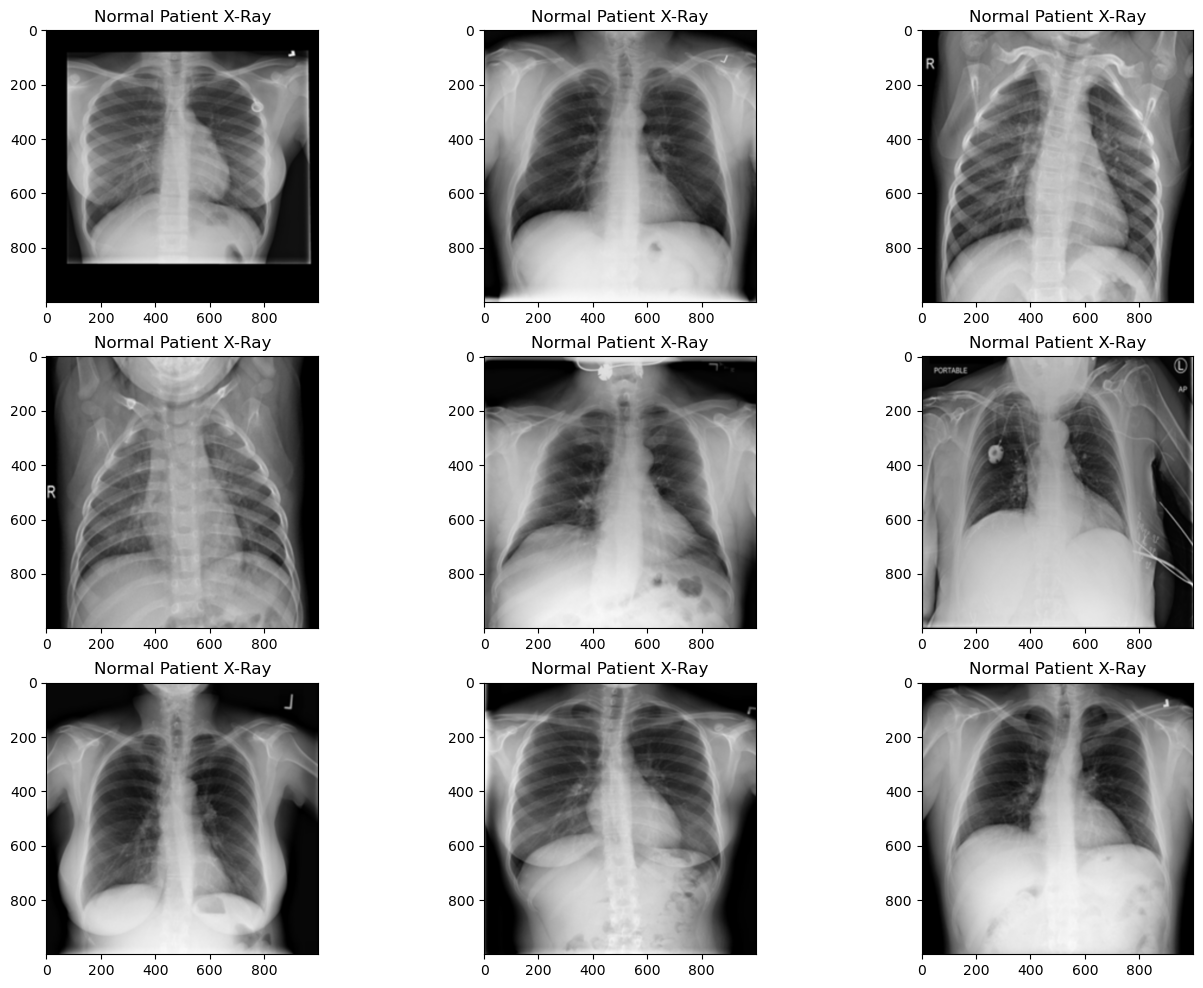

In [4]:
fig = plt.figure(figsize=(16, 12))
for index, image_file in enumerate(os.listdir(NORMAL_DATA_PATH)[:9]):
    ax = fig.add_subplot(3,3, index+1)
    path = NORMAL_DATA_PATH + image_file
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (1000, 1000))
    plt.imshow(image)
    ax.set_title("Normal Patient X-Ray")
plt.show()

#### COVID Chest X-rays 

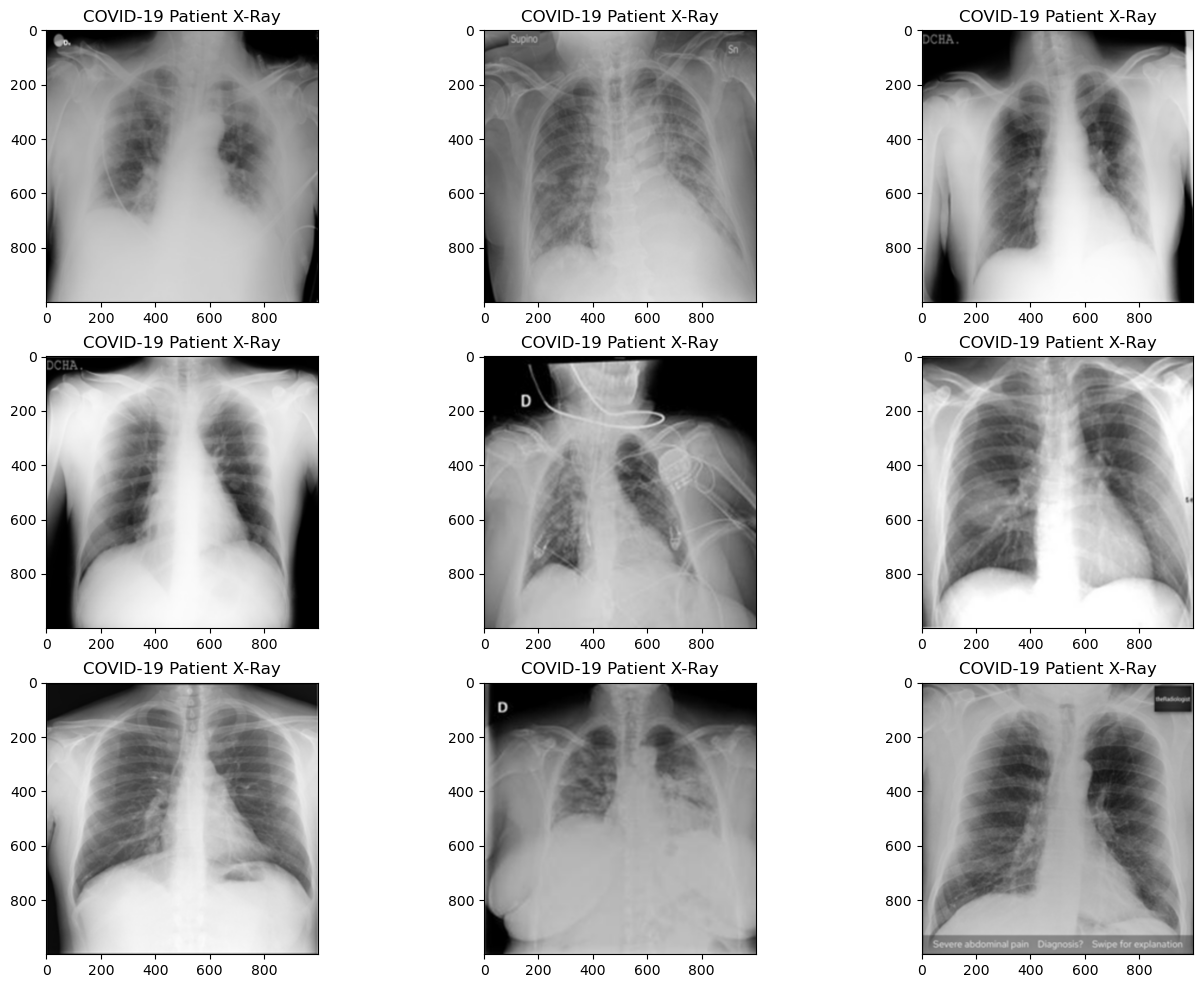

In [5]:
fig = plt.figure(figsize=(16, 12))
for index, image_file in enumerate(os.listdir(COVID_DATA_PATH)[:9]):
    ax = fig.add_subplot(3,3, index+1)
    path = COVID_DATA_PATH+image_file
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (1000, 1000))
    plt.imshow(image)
    ax.set_title("COVID-19 Patient X-Ray")
plt.show()

## Split the dataset in training and testing 

In [1]:
def split_data(source, train, test, split_size, split_type):
    if split_type == "normal": 
        all_files=os.listdir(source)
        down_Sample_files=random.sample(all_files, int(len(all_files) * 0.36))
        train_files=random.sample(down_Sample_files, int(len(down_Sample_files) * split_size))
    else:
        all_files=os.listdir(source)
        train_files=random.sample(all_files, int(len(all_files) * split_size))
    for f in train_files: copyfile(source + f, train + f)
    for f in os.listdir(source):
        if split_type == "normal": 
            if f not in train_files and f in down_Sample_files:
                copyfile(source + f, test + f)
        else:
            if f not in train_files:
                copyfile(source + f, test + f)

In [ ]:
train_normal = BASE_PATH + "\\data\\training\\normal\\"
train_covid = BASE_PATH + "\\data\\training\\covid\\"

test_normal = BASE_PATH + "\\data\\testing\\normal\\"
test_covid = BASE_PATH + "\\data\\testing\\covid\\"

# Use only to split the dataset once
# split_size = 0.8
# split_data(NORMAL_DATA_PATH, train_normal, test_normal, split_size, 'normal')
# split_data(COVID_DATA_PATH, train_covid, test_covid, split_size, "covid")

To handle Imbalance in the dataset, I have structured the training and testing images of both normal and covid x-rays into almost same proportions

In [ ]:
train_normal_files = len(os.listdir(train_normal))
train_covid_files = len(os.listdir(train_covid))

test_normal_files = len(os.listdir(test_normal))
test_covid_files = len(os.listdir(test_covid))

print(f"Training Set - Normal: {train_normal_files}")
print(f"Training Set - Covid: {train_covid_files}")

print(f"Testting Set - Normal: {test_normal_files}")
print(f"Testting Set - Covid: {test_covid_files}")

Let's Setup ImageDataGenerator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow import keras
from keras import layers
# from tensorflow.keras.utils import plot_model
from tensorflow.keras.applications import DenseNet121, EfficientNetB7, ResNet152, EfficientNetB0
from tensorflow.keras.applications.inception_v3 import InceptionV3

In [ ]:
INPUT_SHAPE = 224
training_dir = BASE_PATH + "\data\\training\\"
train_datagen = ImageDataGenerator(
                rescale = 1.0/255.,
                rotation_range=40,
                width_shift_range=0.2,
                height_shift_range=0.2,
                shear_range=0.2,
                zoom_range=0.2,
                fill_mode='nearest',
                horizontal_flip=True,
                vertical_flip=True
)
train_generator = train_datagen.flow_from_directory(training_dir, batch_size=16, 
                                                    target_size=(INPUT_SHAPE, INPUT_SHAPE), class_mode="categorical")

val_dir = BASE_PATH + "\data\\testing\\"
val_datagen = ImageDataGenerator(rescale = 1.0/255.)


val_generator = val_datagen.flow_from_directory(val_dir, batch_size=8,
                                                target_size=(INPUT_SHAPE, INPUT_SHAPE), class_mode="categorical")
gc.collect()

### Model training

In [4]:
MODEL_DENSENET = "densenet"
MODEL_EFFICIENTNET = "efficientnet"
MODEL_RESNET = "resnet152"
MODEL_INCEPTION = "inceptionv3"
CLASSES = ['Normal', 'Covid']
N_CLASSES = len(CLASSES)

In [ ]:
def get_model(base_model_type):
    if base_model_type == MODEL_DENSENET:
        base_model = DenseNet121(
            include_top=False,
            weights="imagenet",
            input_shape=(224, 224, 3),
            # pooling="avg",
        )
    elif base_model_type == MODEL_EFFICIENTNET:
        base_model = EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=(224, 224, 3),
#             pooling="avg",
        
        )
    elif base_model_type == MODEL_RESNET:
        base_model = ResNet152(
            include_top=False,
            weights="imagenet",
            input_shape=(224,224,3),
            pooling="avg",
        )
        for layer in base_model.layers:
            layer.trainable=False
        last_layer = base_model.get_layer('mixed7')
        last_output = last_layer.output
        x = tf.keras.layers.Flatten()(last_output)
        x = tf.keras.layers.Dense(1024, activation="relu")(x)
        x = tf.keras.layers.Dense(512, activation="relu")(x)
    elif base_model_type == MODEL_INCEPTION:
        base_model = InceptionV3(
            include_top=False,
            weights="imagenet",
            input_shape=(224,224,3),
            # pooling="avg",
        )
    else:
        raise Exception("Unsupported model type")
    
    # For DenseNet Model
    # last_layer = base_model.get_layer('conv5_block5_concat')
    # print('last layer output shape: ', last_layer.output_shape)
    # last_output = last_layer.output
    # x = tf.keras.layers.Flatten()(last_output)
    # x = layers.Dense(1024, activation='relu', name = "custom_dense_1")(x)  # Add a new dense layer with 1024 units and ReLU activation
    # x = layers.Dense(512, activation='relu', name = "custom_dense_2")(x)


    # For ResNet Model
    # last_layer = base_model.get_layer('conv5_block3_out')
    # last_output = last_layer.output
    # x = tf.keras.layers.Flatten()(last_output)
    # x = tf.keras.layers.Dense(1024, activation="relu")(x)
    # x = tf.keras.layers.Dense(512, activation="relu")(x)              


    pred_layer = layers.Dense(N_CLASSES, activation="softmax", name="predictions")(x)
    _model = keras.models.Model(inputs=base_model.input, outputs=pred_layer)
    # _model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-08, weight_decay=1e-5), loss="binary_crossentropy", metrics=keras.metrics.AUC())
    _model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), 
                   loss="categorical_crossentropy", 
                   metrics=['acc'])
    
    return _model

In [ ]:
def get_callbacks(model_name):

    callbacks_list = []
    model_logs = model_name + '_model_logs_' + str(datetime.datetime.now())
    os.mkdir(model_logs)
    csv_logger_path = os.path.join(os.getcwd(), model_logs, "TF_training_logs.csv")
    callbacks_list.append(keras.callbacks.CSVLogger(csv_logger_path))

    # dafuq is max used with val_loss?
    model_ckpt_path = os.path.join(os.getcwd(), model_logs, "TF-Model-Checkpoint")
    callbacks_list.append(keras.callbacks.ModelCheckpoint(filepath=model_ckpt_path, monitor='val_loss', mode='min', save_best_only=True))

    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0.0001, patience=3, verbose=0, mode='min')
    callbacks_list.append(early_stop)
    reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.1, patience=2, min_lr=1e-8, verbose=0)
    callbacks_list.append(reduce_lr)

    return callbacks_list

In [ ]:
model = get_model(MODEL_INCEPTION)
callbacks = get_callbacks(MODEL_INCEPTION)

In [ ]:
steps_per_epoch = train_generator.n//train_generator.batch_size
validation_steps = val_generator.n//val_generator.batch_size
history = model.fit(
                    train_generator,
                    epochs = 3,
                    steps_per_epoch = steps_per_epoch,
                    validation_data = val_generator,
                    validation_steps = validation_steps
                )

In [ ]:
for layers in model.layers:
    layers.trainable = True

In [ ]:
history = model.fit(
                    train_generator,
                    epochs = 50,
                    steps_per_epoch = steps_per_epoch,
                    validation_data = val_generator,
                    validation_steps = validation_steps,
                    callbacks = callbacks
                )

In [1]:
# local_weights_file = r"C:\Users\Sahil\inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5"
# pre_trained_model.load_weights(local_weights_file)